# Proyek Analisis Data: Bike Sharing
- **Nama:** Khatama Putra
- **Email:** khatamap@gmail.com
- **ID Dicoding:** khatamap

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca (weathersit) dan musim (season) terhadap jumlah penyewaan sepeda harian?
- Apakah ada perbedaan pola penyewaan sepeda antara hari kerja (workingday) dan hari libur (holiday)?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Loading day.csv

In [34]:
day_df = pd.read_csv('data/day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


#### Loading hour.csv

In [35]:
hour_df = pd.read_csv('data/hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


#### **Insight**
- Berhasil memuat dua tabel utama: day_df (data harian) dan hour_df (data per jam).
- Dataset ini memuat informasi terkait penyewaan sepeda beserta faktor lingkungan seperti cuaca, musim, suhu, dan kelembaban.

### Assessing Data

#### Menilai day_df

In [36]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [37]:
day_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [38]:
day_df.duplicated().sum()

np.int64(0)

In [39]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


#### Menilai df_hour

In [40]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [41]:
hour_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [42]:
hour_df.duplicated().sum()

np.int64(0)

In [43]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


#### **Insight**
- Tidak ditemukan missing value pada kedua tabel (day_df dan hour_df), data tergolong lengkap.
- Tidak ditemukan data duplikat, artinya setiap baris merepresentasikan data unik.
- Terdapat kesalahan tipe data pada kolom dteday. Saat ini masih berupa object, seharusnya diubah menjadi tipe datetime agar bisa diolah berdasarkan waktu.
- Kolom season sulit dipahami karena nilainya dalam numerik 1,2,3,4.
- Beberapa nama kolom agak sulit dipahami (seperti yr, mnth, hr, weathersit, dll).

### Cleaning Data

#### Memperbaiki Tipe Data

In [44]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

print('Tipe data day_df["dteday"]:', day_df['dteday'].dtype)
print('Tipe data hour_df["dteday"]:', hour_df['dteday'].dtype)

Tipe data day_df["dteday"]: datetime64[ns]
Tipe data hour_df["dteday"]: datetime64[ns]


#### Mengganti Nama Kolom

In [45]:
day_df.rename(columns={
    'yr': 'year',
    'mnth': 'month',
    'holiday': 'is_holiday',
    'workingday': 'is_workingday',
    'weathersit': 'weather_cond',
    'temp': 'temperature',
    'atemp': 'feeling_temperature',
    'hum': 'humidity',
    'cnt': 'total_count'
}, inplace=True)

print("Nama kolom baru day_df:", day_df.columns)

Nama kolom baru day_df: Index(['instant', 'dteday', 'season', 'year', 'month', 'is_holiday', 'weekday',
       'is_workingday', 'weather_cond', 'temperature', 'feeling_temperature',
       'humidity', 'windspeed', 'casual', 'registered', 'total_count'],
      dtype='object')


In [46]:
hour_df.rename(columns={
    'yr': 'year',
    'mnth': 'month',
    'holiday': 'is_holiday',
    'hr': 'hour',
    'workingday': 'is_workingday',
    'weathersit': 'weather_cond',
    'temp': 'temperature',
    'atemp': 'feeling_temperature',
    'hum': 'humidity',
    'cnt': 'total_count'
}, inplace=True)

print("Nama kolom baru hour_df:", hour_df.columns)

Nama kolom baru hour_df: Index(['instant', 'dteday', 'season', 'year', 'month', 'hour', 'is_holiday',
       'weekday', 'is_workingday', 'weather_cond', 'temperature',
       'feeling_temperature', 'humidity', 'windspeed', 'casual', 'registered',
       'total_count'],
      dtype='object')


#### Mengkonversi Isi Kolom

In [47]:
day_df['month'] = day_df['dteday'].dt.month_name()
day_df['year'] = day_df['dteday'].dt.year

day_df['season'] = day_df['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

day_df['weather_cond'] = day_df['weather_cond'].map({
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Severe Weather'
})

day_df.head()

,instant,dteday,season,year,month,is_holiday,weekday,is_workingday,weather_cond,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,Spring,2011,January,0,6,0,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,January,0,0,0,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,January,0,1,1,Clear/Partly Cloudy,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,January,0,2,1,Clear/Partly Cloudy,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,January,0,3,1,Clear/Partly Cloudy,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [48]:
hour_df['month'] = hour_df['dteday'].dt.month_name()
hour_df['year'] = hour_df['dteday'].dt.year

hour_df['season'] = hour_df['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

hour_df['weather_cond'] = hour_df['weather_cond'].map({
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Severe Weather'
})

hour_df.head()

,instant,dteday,season,year,month,hour,is_holiday,weekday,is_workingday,weather_cond,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count
0,1,2011-01-01,Spring,2011,January,0,0,6,0,Clear/Partly Cloudy,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,Spring,2011,January,1,0,6,0,Clear/Partly Cloudy,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,Spring,2011,January,2,0,6,0,Clear/Partly Cloudy,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,Spring,2011,January,3,0,6,0,Clear/Partly Cloudy,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,Spring,2011,January,4,0,6,0,Clear/Partly Cloudy,0.24,0.2879,0.75,0.0,0,1,1


#### **Insight**
- Kolom dteday pada day_df dan hour_df telah diubah menjadi tipe datetime.
- Nama kolom yang disingkat pada day_df dan hour_df telah diubah menjadi deskriptif (contoh: yr menjadi year).
- Nilai numerik pada kolom season dan weather_cond pada day_df dan df_hour telah dikonversi menjadi label kategori (Spring, Summer, Clear, dll) agar visualisasi lebih mudah dipahami.

## Exploratory Data Analysis (EDA)

### Explore day_df

In [49]:
day_df.sample(10)

,instant,dteday,season,year,month,is_holiday,weekday,is_workingday,weather_cond,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count
354,355,2011-12-21,Spring,2011,December,0,3,1,Misty/Cloudy,0.428333,0.428017,0.858333,0.221400,107,2553,2660
229,230,2011-08-18,Fall,2011,August,0,4,1,Clear/Partly Cloudy,0.711667,0.662258,0.654583,0.233208,639,3166,3805
219,220,2011-08-08,Fall,2011,August,0,1,1,Clear/Partly Cloudy,0.765000,0.703283,0.592083,0.192175,846,3480,4326
464,465,2012-04-09,Summer,2012,April,0,1,1,Clear/Partly Cloudy,0.489167,0.476638,0.317500,0.358196,905,4680,5585
118,119,2011-04-29,Summer,2011,April,0,5,1,Clear/Partly Cloudy,0.510000,0.497463,0.457083,0.240063,878,3717,4595
253,254,2011-09-11,Fall,2011,September,0,0,0,Clear/Partly Cloudy,0.653333,0.609229,0.713750,0.115054,1633,3413,5046
231,232,2011-08-20,Fall,2011,August,0,6,0,Clear/Partly Cloudy,0.697500,0.648996,0.674167,0.104467,1914,3277,5191
76,77,2011-03-18,Spring,2011,March,0,5,1,Clear/Partly Cloudy,0.540000,0.527009,0.525217,0.231017,884,2355,3239
595,596,2012-08-18,Fall,2012,August,0,6,0,Clear/Partly Cloudy,0.678333,0.618071,0.603333,0.177867,2827,5038,7865
78,79,2011-03-20,Spring,2011,March,0,0,0,Clear/Partly Cloudy,0.332500,0.325750,0.473750,0.207721,1047,1424,2471


In [50]:
day_df.describe(include="all")

,instant,dteday,season,year,month,is_holiday,weekday,is_workingday,weather_cond,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count
count,731.000000,731,731,731.000000,731,731.000000,731.000000,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4,NaN,12,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,NaN,January,NaN,NaN,NaN,Clear/Partly Cloudy,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188,NaN,62,NaN,NaN,NaN,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,2011.500684,NaN,0.028728,2.997264,0.683995,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,2011.000000,NaN,0.000000,0.000000,0.000000,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,2011.000000,NaN,0.000000,1.000000,0.000000,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,2012.000000,NaN,0.000000,3.000000,1.000000,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,2012.000000,NaN,0.000000,5.000000,1.000000,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,2012.000000,NaN,1.000000,6.000000,1.000000,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [51]:
print("Rata-rata penyewaan berdasarkan musim:")
print(day_df.groupby(by="season").agg({
    "total_count": ["max", "min", "mean", "sum"]
}))

print("\n--------------------------------------------\n")

print("Rata-rata penyewaan berdasarkan cuaca:")
print(day_df.groupby(by="weather_cond").agg({
    "total_count": ["max", "min", "mean", "sum"]
}))

Rata-rata penyewaan berdasarkan musim:
       total_count                            
               max   min         mean      sum
season                                        
Fall          8714  1115  5644.303191  1061129
Spring        7836   431  2604.132597   471348
Summer        8362   795  4992.331522   918589
Winter        8555    22  4728.162921   841613

--------------------------------------------

Rata-rata penyewaan berdasarkan cuaca:
                    total_count                           
                            max  min         mean      sum
weather_cond                                              
Clear/Partly Cloudy        8714  431  4876.786177  2257952
Light Snow/Rain            4639   22  1803.285714    37869
Misty/Cloudy               8362  605  4035.862348   996858


In [52]:
print(day_df.groupby(by="is_workingday").agg({
    "casual": "mean",
    "registered": "mean",
    "total_count": "mean"
}))

                    casual   registered  total_count
is_workingday                                       
0              1371.134199  2959.034632  4330.168831
1               606.570000  3978.250000  4584.820000


### Explore hour_df

In [53]:
hour_df.sample(10)

,instant,dteday,season,year,month,hour,is_holiday,weekday,is_workingday,weather_cond,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count
13195,13196,2012-07-09,Fall,2012,July,0,0,1,1,Misty/Cloudy,0.68,0.6364,0.89,0.0896,6,33,39
10375,10376,2012-03-13,Spring,2012,March,10,0,2,1,Clear/Partly Cloudy,0.52,0.5000,0.77,0.2239,28,115,143
5097,5098,2011-08-05,Fall,2011,August,7,0,5,1,Clear/Partly Cloudy,0.66,0.6061,0.78,0.1343,23,247,270
8887,8888,2012-01-11,Spring,2012,January,4,0,3,1,Clear/Partly Cloudy,0.20,0.2121,0.80,0.1343,0,2,2
5703,5704,2011-08-31,Fall,2011,August,2,0,3,1,Clear/Partly Cloudy,0.56,0.5303,0.73,0.0000,1,5,6
1937,1938,2011-03-26,Summer,2011,March,12,0,6,0,Clear/Partly Cloudy,0.30,0.2879,0.36,0.1940,98,129,227
3904,3905,2011-06-16,Summer,2011,June,14,0,4,1,Misty/Cloudy,0.72,0.6667,0.54,0.3284,39,114,153
6577,6578,2011-10-06,Winter,2011,October,15,0,4,1,Clear/Partly Cloudy,0.58,0.5455,0.46,0.1343,62,157,219
2096,2097,2011-04-02,Summer,2011,April,5,0,6,0,Misty/Cloudy,0.24,0.2424,0.75,0.1642,1,4,5
6055,6056,2011-09-14,Fall,2011,September,21,0,3,1,Misty/Cloudy,0.66,0.6212,0.65,0.2239,24,189,213


In [54]:
hour_df.describe(include="all")

,instant,dteday,season,year,month,hour,is_holiday,weekday,is_workingday,weather_cond,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count
count,17379.0000,17379,17379,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,NaN,12,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,NaN,July,NaN,NaN,NaN,NaN,Clear/Partly Cloudy,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,NaN,1488,NaN,NaN,NaN,NaN,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,2011.502561,NaN,11.546752,0.028770,3.003683,0.682721,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,2011.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,2011.000000,NaN,6.000000,0.000000,1.000000,0.000000,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,2012.000000,NaN,12.000000,0.000000,3.000000,1.000000,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,2012.000000,NaN,18.000000,0.000000,5.000000,1.000000,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,2012.000000,NaN,23.000000,1.000000,6.000000,1.000000,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [55]:
print("Rata-rata penyewaan berdasarkan musim:")
print(hour_df.groupby(by="season").agg({
    "total_count": ["max", "min", "mean", "sum"]
}))

print("\n--------------------------------------------\n")

print("Rata-rata penyewaan berdasarkan cuaca:")
print(hour_df.groupby(by="weather_cond").agg({
    "total_count": ["max", "min", "mean", "sum"]
}))

Rata-rata penyewaan berdasarkan musim:
       total_count                         
               max min        mean      sum
season                                     
Fall           977   1  236.016237  1061129
Spring         801   1  111.114569   471348
Summer         957   1  208.344069   918589
Winter         967   1  198.868856   841613

--------------------------------------------

Rata-rata penyewaan berdasarkan cuaca:
                    total_count                         
                            max min        mean      sum
weather_cond                                            
Clear/Partly Cloudy         977   1  204.869272  2338173
Light Snow/Rain             891   1  111.579281   158331
Misty/Cloudy                957   1  175.165493   795952
Severe Weather              164  23   74.333333      223


In [56]:
print(hour_df.groupby(by="is_workingday").agg({
    "casual": "mean",
    "registered": "mean",
    "total_count": "mean"
}))

                  casual  registered  total_count
is_workingday                                    
0              57.441422  123.963910   181.405332
1              25.561315  167.646439   193.207754


### Merge Tabel

Karena isi dari day_df dan hour_df kurang lebih sama, maka kedua tabel akan digabungkan menjadi main_df.

In [57]:
main_df = hour_df.merge(day_df['dteday'], on='dteday', how='left')

### **Insight**
- Rata-rata penyewaan tertinggi terjadi di musim gugur/Fall (5644) dan ketika cuaca cerah (4876).
- Rata-rata penyewaan paling rendah terjadi di musim semi/Spring (2604) dan ketika cuaca sedang hujan (1803).

Analisis: Kemungkinan di fase Spring ini cuaca masih transisi dari musim dingin (masih agak dingin/basah) sehingga orang enggan bersepeda. Kemudian, masuk akal jika orang enggan bersepeda saat hujan atau bersalju.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

C:\Users\Khatama\AppData\Local\Temp\ipykernel_25216\194424515.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Khatama\AppData\Local\Temp\ipykernel_25216\194424515.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


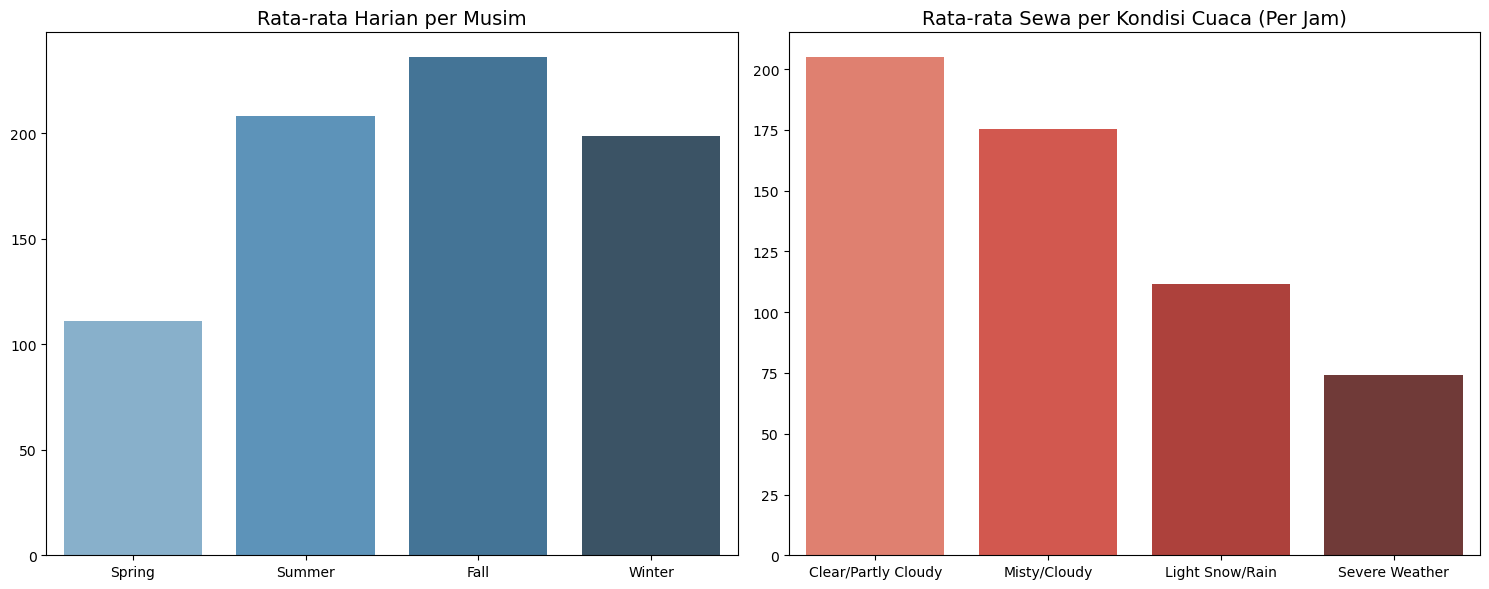

In [58]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

sns.barplot(
    x="season", 
    y="total_count",
    data=main_df, 
    ax=ax[0], 
    palette="Blues_d", 
    errorbar=None,
    order=['Spring', 'Summer', 'Fall', 'Winter']
)
ax[0].set_title("Rata-rata Harian per Musim", fontsize=14)
ax[0].set_xlabel(None)
ax[0].set_ylabel(None)

sns.barplot(
    x="weather_cond", 
    y="total_count", 
    data=main_df, 
    ax=ax[1], 
    palette="Reds_d", 
    errorbar=None
)
ax[1].set_title("Rata-rata Sewa per Kondisi Cuaca (Per Jam)", fontsize=14)
ax[1].set_xlabel(None)
ax[1].set_ylabel(None)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

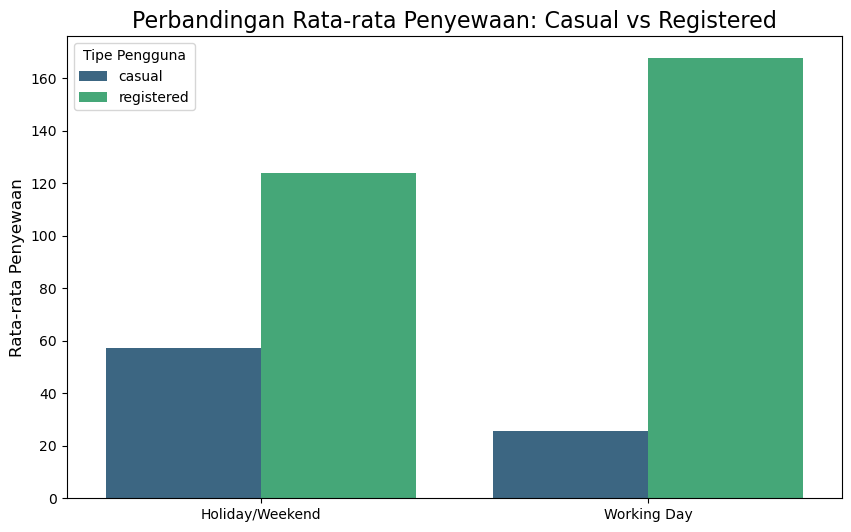

In [59]:
by_workingday = main_df.groupby(by="is_workingday").agg({
    "casual": "mean",
    "registered": "mean"
}).reset_index()

by_workingday['is_workingday'] = by_workingday['is_workingday'].map({
    0: 'Holiday/Weekend',
    1: 'Working Day'
})

by_workingday_melt = by_workingday.melt(
    id_vars="is_workingday",
    var_name="user_type",
    value_name="avg_count"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x="is_workingday", 
    y="avg_count", 
    hue="user_type", 
    data=by_workingday_melt, 
    palette="viridis"
)

plt.title("Perbandingan Rata-rata Penyewaan: Casual vs Registered", fontsize=16)
plt.xlabel(None)
plt.ylabel("Rata-rata Penyewaan", fontsize=12)
plt.legend(title="Tipe Pengguna")
plt.show()

### **Insight**
- Terlihat bahwa musim gugur (Fall) memiliki rata-rata penyewaan tertinggi. Sementara itu, kondisi cuaca cerah (Clear/Partly Cloudy) menjadi faktor dominan yang mendorong orang untuk menyewa sepeda.
- Grafik menunjukkan perbedaan perilaku yang kontras. Pengguna terdaftar (Registered) mendominasi penggunaan pada hari kerja (Working Day), sedangkan pengguna biasa (Casual) justru lebih aktif menyewa pada hari libur (Holiday/Weekend).

## Analisis Lanjutan (Opsional)

Menggunakan teknik binning (pengelompokkan) dengan membuat kategori baru:
- Temperature (Suhu) dikelompokkan menjadi Cold, Mild, Hot. Ini akan membantu untuk melihat tren penyewaan berdasarkan kenyamanan suhu.
- Hour (Jam) dikelompokkan menjadi Morning, Afternoon, Evening. Ini akan membantu untuk melihat tren penyewaan berdasarkan waktu.

### Pengelompokkan Suhu

In [60]:
def categorize_temp(temp):
    if temp < 0.3:
        return 'Cold'
    elif temp < 0.6:
        return 'Mild'
    else:
        return 'Hot'

main_df['temp_category'] = main_df['temperature'].apply(categorize_temp)

print("Rata-rata penyewaan berdasarkan kategori suhu:")
print(main_df.groupby(by="temp_category").agg({
    "total_count": ["mean", "min", "max"]
}).sort_values(by=('total_count', 'mean'), ascending=False))

Rata-rata penyewaan berdasarkan kategori suhu:
              total_count         
                     mean min  max
temp_category                     
Hot            263.833948   1  977
Mild           169.199225   1  948
Cold            77.341803   1  729


### Pengelompokkan Jam/Waktu

In [61]:
def categorize_time_of_day(hour):
    if 0 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    else:
        return 'Evening'

main_df['time_of_day'] = main_df['hour'].apply(categorize_time_of_day)

print("Rata-rata sewa per jam (berdasarkan kategori waktu):")
print(main_df.groupby(by="time_of_day").agg({
    "total_count": ["mean", "min", "max"]
}).sort_values(by=('total_count', 'mean'), ascending=False))

Rata-rata sewa per jam (berdasarkan kategori waktu):
            total_count         
                   mean min  max
time_of_day                     
Afternoon    262.244719   3  783
Evening      259.507454   2  977
Morning      117.395553   1  839


### Visualisasi

C:\Users\Khatama\AppData\Local\Temp\ipykernel_25216\1606120662.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Khatama\AppData\Local\Temp\ipykernel_25216\1606120662.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


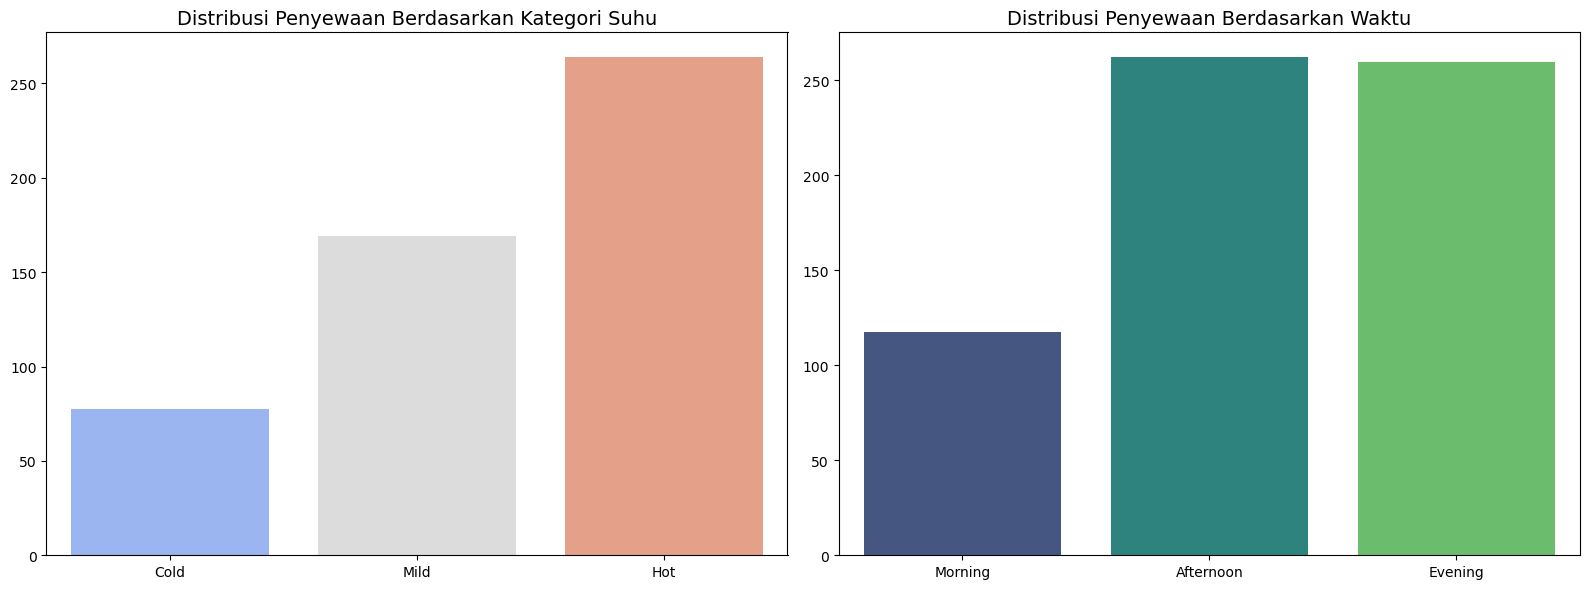

In [62]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.barplot(
    x="temp_category", 
    y="total_count", 
    data=main_df,
    order=['Cold', 'Mild', 'Hot'],
    palette="coolwarm",
    errorbar=None,
    ax=ax[0]
)
ax[0].set_title("Distribusi Penyewaan Berdasarkan Kategori Suhu", fontsize=14)
ax[0].set_xlabel(None)
ax[0].set_ylabel(None)

sns.barplot(
    x="time_of_day", 
    y="total_count", 
    data=main_df, 
    order=['Morning', 'Afternoon', 'Evening'],
    palette="viridis",
    errorbar=None,
    ax=ax[1]
)
ax[1].set_title("Distribusi Penyewaan Berdasarkan Waktu", fontsize=14)
ax[1].set_xlabel(None)
ax[1].set_ylabel(None)

plt.tight_layout()
plt.show()

## Conclusion

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca dan musim terhadap jumlah penyewaan sepeda harian?

Berdasarkan analisis data (Season, Weather Condition, dan Temperature Binning), dapat disimpulkan bahwa faktor lingkungan memiliki pengaruh yang sangat vital terhadap minat penyewaan sepeda:

1.  Musim:
    - Penyewaan mencapai puncaknya pada musim Gugur (Fall).
    - Sebaliknya, musim Semi (Spring) memiliki tingkat penyewaan terendah.
2.  Kondisi Cuaca:
    - Pengguna sangat menyukai cuaca yang Cerah (Clear).
    - Minat menyewa turun drastis saat terjadi hujan atau salju.
3.  Suhu:
    - Data binning menunjukkan korelasi positif yang kuat antara suhu hangat dan jumlah sewa.
    - Kategori suhu Hot memiliki rata-rata penyewaan tertinggi (5665 sewa/hari).
    - Kategori Mild berada di posisi kedua (4462 sewa/hari).
    - Kategori Cold memiliki rata-rata terendah (2389 sewa/hari).

Owner dapat memprediksi lonjakan permintaan saat ramalan cuaca menunjukkan suhu hangat dan cuaca cerah, serta melakukan maintenance unit saat suhu dingin.

### Pertanyaan 2: Apakah ada perbedaan pola penyewaan sepeda antara hari kerja dan hari libur?

Ya, terdapat pola perilaku yang sangat kontras antara hari kerja (Working Day) dan hari libur (Holiday/Weekend):

1.  Perbedaan Tipe Pengguna:
    - Hari Kerja: Didominasi oleh pengguna terdaftar (Registered). Ini mengindikasikan sepeda digunakan sebagai alat transportasi.
    - Hari Libur: Didominasi oleh peningkatan pengguna biasa (Casual). Ini menunjukkan sepeda digunakan sebagai rekreasi atau liburan.
2.  Jam Sibuk:
    - Secara keseluruhan (rata-rata gabungan), waktu tersibuk adalah Siang Hari (Afternoon) dengan rata-rata 262 sewa/jam dan Sore Hari (Evening) dengan 259 sewa/jam.
    - Pagi Hari (Morning) memiliki rata-rata terendah (117 sewa/jam) karena aktivitas pagi hanya terkonsentrasi di jam keberangkatan kerja yang singkat (jam 7-8).

Pada hari kerja, pastikan ketersediaan unit pada pagi hari dan pada sore hari.

## Export CSV

In [63]:
main_df.to_csv("dashboard/main_data.csv", index=False)

print("Berhasil menggabungkan data! Shape baru:", main_df.shape)
main_df.head()

Berhasil menggabungkan data! Shape baru: (17379, 19)


,instant,dteday,season,year,month,hour,is_holiday,weekday,is_workingday,weather_cond,temperature,feeling_temperature,humidity,windspeed,casual,registered,total_count,temp_category,time_of_day
0,1,2011-01-01,Spring,2011,January,0,0,6,0,Clear/Partly Cloudy,0.24,0.2879,0.81,0.0,3,13,16,Cold,Morning
1,2,2011-01-01,Spring,2011,January,1,0,6,0,Clear/Partly Cloudy,0.22,0.2727,0.80,0.0,8,32,40,Cold,Morning
2,3,2011-01-01,Spring,2011,January,2,0,6,0,Clear/Partly Cloudy,0.22,0.2727,0.80,0.0,5,27,32,Cold,Morning
3,4,2011-01-01,Spring,2011,January,3,0,6,0,Clear/Partly Cloudy,0.24,0.2879,0.75,0.0,3,10,13,Cold,Morning
4,5,2011-01-01,Spring,2011,January,4,0,6,0,Clear/Partly Cloudy,0.24,0.2879,0.75,0.0,0,1,1,Cold,Morning
